In [29]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [30]:
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

In [32]:
df = pd.read_csv(r'/Users/a/Downloads/spotify_churn_dataset.csv')

In [35]:
features = ['listening_time', 'skip_rate']

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)


In [36]:
df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby('Cluster')[features].mean()

cluster_summary.to_csv(
    'outputs/tables/rq6_cluster_summary.csv'
)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

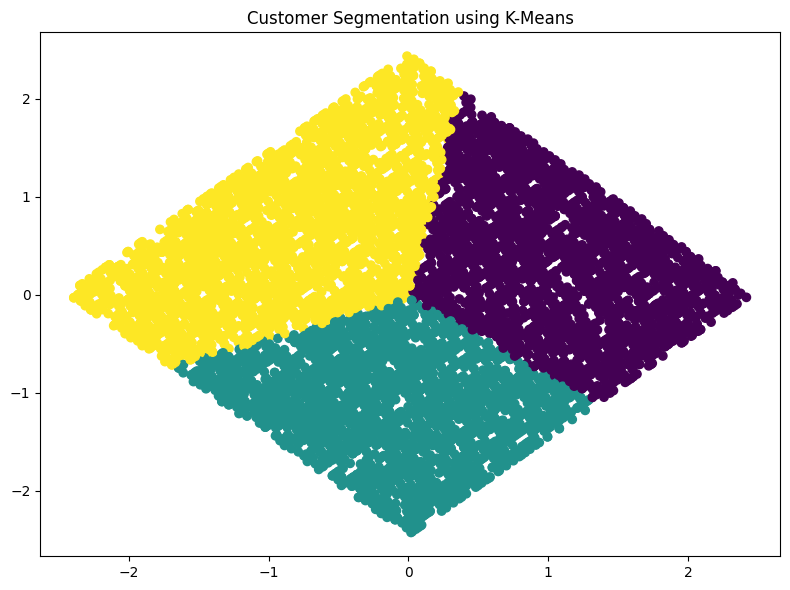

In [37]:
plt.figure(figsize=(8,6))
plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=df['Cluster']
)

plt.title('Customer Segmentation using K-Means')
plt.tight_layout()
plt.savefig('outputs/figures/rq6_customer_clusters.pdf')
plt.show()